In [1]:
import os
import sys
sys.path.append('..')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import config
import data_processing

import warnings
warnings.filterwarnings('ignore')

# Constants

In [40]:
# Directory containing the images of each scene; used for plotting
IMG_DIR = '../../motion_distributions/data/train'
# Color palettes
CUSTOM_PALETTE = {
    'purple': '#673C4F',
    'blue': '#1C77C3',
    'light_blue': '#40BCD8',
    'green': '#68D89B',
    'yellow': '#FDCA40',
    'orange': '#F39237',
    'red': '#D63230'
}
PATH_PALETTE = {
    'straight_path': '#F39237',
    'no_straight_path': '#1C77C3',
    'other': '#68D89B',
}
# Set global font sizes
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 24,
    'axes.labelsize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 18
})
# Saving figures?
SAVING_FIGURES = False

# Helpers

In [3]:
def assign_ground_truth_response(scene_name:str) -> bool:
    """
    Assigns the ground truth response for a given scene name.
    """
    if 'yescol' in scene_name:
        return True
    elif 'nocol' in scene_name:
        return False
    elif 'scene' in scene_name:
        return True
    else:
        raise ValueError(f"Unknown scene name: {scene_name}")


In [5]:
def assign_experiment_label(x):
    """
    Assigns the experiment label for a given scene name.
    """
    if 'yessp' in x:
        return 'exp1'
    elif 'nosp' in x:
        return 'exp1'
    elif 'scene' in x:
        return 'exp2'
    else:
        raise ValueError(f"Unknown scene name: {x}")

In [6]:
def assign_sim_time_condition(x):
    """
    Assigns the simulation time condition for a given scene name.
    """
    if 'high' in x:
        return 'high'
    elif 'med' in x:
        return 'med'
    elif 'low' in x:
        return 'low'
    else:
        return 'other'

In [7]:
def assign_path_condition(x):
    """
    Assigns the path condition for a given scene name.
    """
    A = 11
    if 'yessp' in x:
        return 'straight_path'
    if 'nosp' in x:
        return 'no_straight_path'
    if 'scene' in x:
        scene_num = int(x.split('_')[1])
        scene_idx = int(x.split('_')[-1])
        if scene_num == 1 and scene_idx <= A:
            return 'straight_path'
        if scene_num == 1 and scene_idx > A:
            return 'no_straight_path'
        if scene_num == 2:
            return 'straight_path'
    raise ValueError


# Import and wrangle empirical and model data

In [18]:
# Import empirical gaze data
gaze = data_processing.import_gaze_data(
    os.path.join('..', config.DATA_DIR, 'experiment1'))

Processing ASC files: 100%|██████████| 12/12 [00:19<00:00,  1.61s/it]


In [19]:
# Subset the data to only include the relevant trial data
trial_gaze_data = data_processing.get_intra_trial_data(gaze)

In [20]:
# Convert the time column to milliseconds
trial_gaze_data['total_gaze_time'] = trial_gaze_data.groupby(
    ['subject_id', 'scene_name']).time.transform(lambda x: (x - x.min())*1000)

In [21]:
# Rename the response_time column to stimulus_time
trial_gaze_data.rename(columns={'response_time': 'stimulus_time'}, inplace=True)

In [22]:
# Drop the button_response, trial_duration, and block_duration columns
trial_gaze_data.drop(
    columns=['button_response', 'trial_duration', 'block_duration'],
    inplace=True)

In [23]:
# Assign the ground truth response for each scene
trial_gaze_data['correct_response'] = trial_gaze_data.scene_name.apply(
    assign_ground_truth_response)

In [24]:
# Extract ground-truth button responses, and participant button responses
gt_button_responses, participant_button_responses = data_processing.get_participant_responses(gaze)

In [25]:
# Transform the trial_duration column to milliseconds, store in new column
participant_button_responses['judgment_time'] = participant_button_responses.trial_duration.transform(lambda x: x*1000)

In [26]:
# Merge the trial-level gaze data with the participant button responses
trial_gaze_data = pd.merge(
        left=trial_gaze_data,
        right=participant_button_responses,
        on=['subject_id', 'scene_name']
    )

In [27]:
# Merge the trial-level gaze data with the ground-truth button responses
trial_gaze_data = pd.merge(
        left=trial_gaze_data,
        right=gt_button_responses,
        on=['subject_id', 'button_response']
    )

In [28]:
# Transform the ground-truth button_value column to a boolean
trial_gaze_data['button_value'] = trial_gaze_data.button_value.transform(
        lambda x: True if 'yes' in x else False if 'no' in x else None)

In [29]:
# Assign whether the participant's response was correct to each row
trial_gaze_data['correct'] = (trial_gaze_data['button_value'] == trial_gaze_data['correct_response']).astype(int)

In [30]:
# Assign the path condition labels to each row
trial_gaze_data['path_condition'] = trial_gaze_data.scene_name.apply(assign_path_condition)

In [31]:
# Assign the simulation time condition to each row
trial_gaze_data['sim_time_condition'] = trial_gaze_data.scene_name.apply(assign_sim_time_condition)

In [32]:
# Label the scenes according to which experiment they're from
trial_gaze_data['experiment'] = trial_gaze_data.scene_name.apply(assign_experiment_label)

In [33]:
# Get simulation model predictions
simulation_data = data_processing.get_simulation_model_predictions(
    os.path.join('..',config.DATA_DIR, 'simulation_results.json'))

In [34]:
# Merge gaze data with simulation model predictions
trial_gaze_data = trial_gaze_data.merge(right=simulation_data[
    ['sim_time', 'scene_name']], on='scene_name')

In [35]:
# Determine mean accuracy across subjects and scenes
mean_accuracy_subj = trial_gaze_data.groupby(
    'subject_id').correct.mean().reset_index()
mean_accuracy_scene = trial_gaze_data.groupby(
    'scene_name').correct.mean().reset_index()
mean_accuracy_subj = mean_accuracy_subj.rename(
    columns={'correct': 'mean_acc_subj'})
mean_accuracy_scene = mean_accuracy_scene.rename(
    columns={'correct': 'mean_acc_scene'})

In [36]:
# Merge accuracy results with the beahavior data
trial_gaze_data = pd.merge(
    left=trial_gaze_data, right=mean_accuracy_subj, on='subject_id')
trial_gaze_data = pd.merge(
    left=trial_gaze_data, right=mean_accuracy_scene, on='scene_name')

# Plotting the behavioral (response time, accuracy) data

In [38]:
# Calculate mean judgment time across scenes, path, and sim time conditions
mean_scene_rt = trial_gaze_data[trial_gaze_data['experiment'] == 'exp1'].groupby(
    [
        'scene_name',
        'path_condition',
        'sim_time',
        'sim_time_condition'
    ]).judgment_time.mean().reset_index()

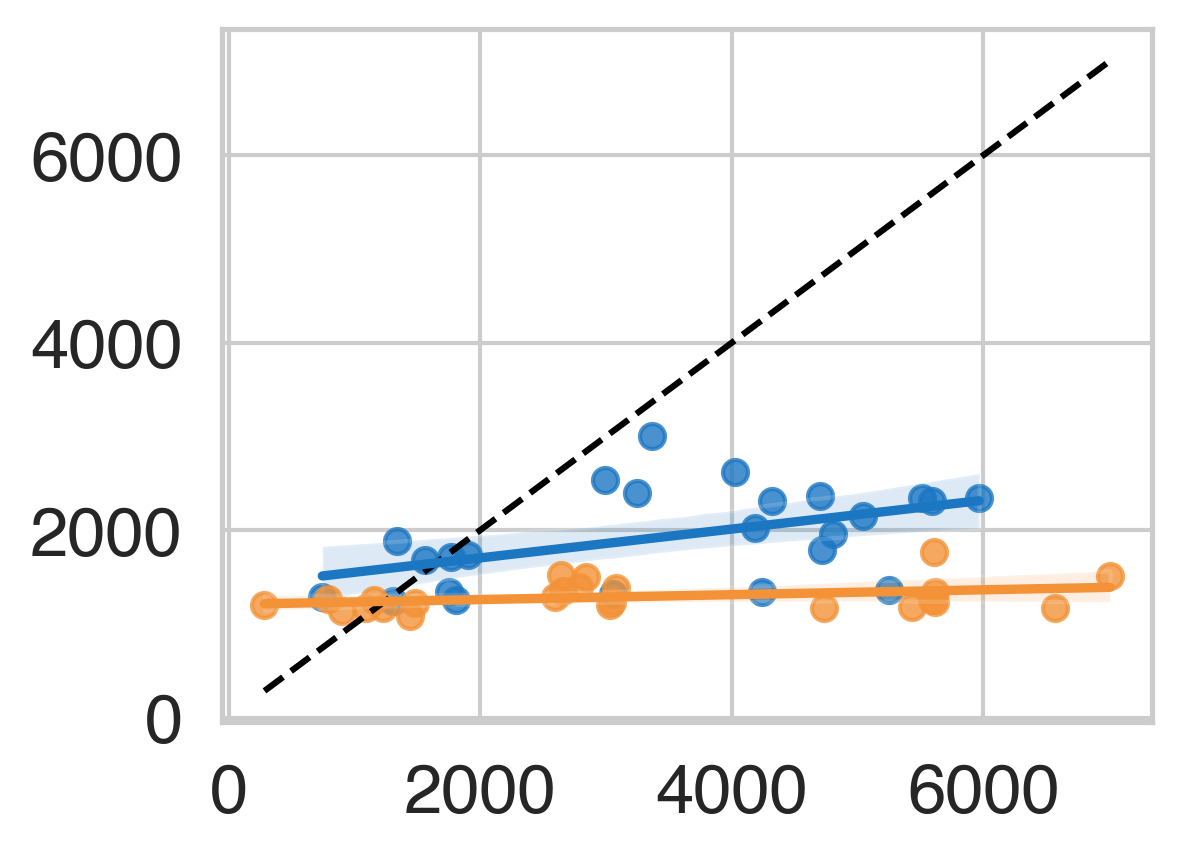

In [ ]:
# Create a range of x values for the plot (sim time)
x = np.linspace(
    min(min(mean_scene_rt.sim_time), min(mean_scene_rt.judgment_time)),
    max(max(mean_scene_rt.sim_time), max(mean_scene_rt.judgment_time)),
    12
)
# Set the theme parameters
sns.set_theme(
    style='whitegrid',
    font_scale=1.5,
    rc={
        'figure.dpi':300,
        'font.family':'sans-serif',
        'font.sans-serif':['Helvetica'],
        'figure.figsize':(2,1.5),
    },
)
# Create a figure and axis
fig, ax = plt.subplots(figsize=(4,3))
# Plot the line for expected RTs under perfect, pure simulation
ax.plot(x,
        x, 
        linestyle='dashed',
        color='Black',
    )
# Plot the empirical data for the no-straight path condition
sns.regplot(x='sim_time',
            y='judgment_time',
            data=mean_scene_rt[mean_scene_rt.path_condition == 'no_straight_path'],
            label="No straight path",
            ax=ax,
            color=PATH_PALETTE['no_straight_path']
        )
# Plot the empirical data for the straight path condition
sns.regplot(x='sim_time',
            y='judgment_time',
            data=mean_scene_rt[mean_scene_rt.path_condition == 'straight_path'], 
            label="Straight path",
            ax=ax,
            color=PATH_PALETTE['straight_path']
        )
# Set the x and y labels
ax.set_xlabel('')
ax.set_ylabel('')
# Save the figure
if SAVING_FIGURES:
    plt.savefig(
        os.path.join('..', config.FIGURE_STORE, 'rt_replication_b.pdf'),
        bbox_inches='tight')

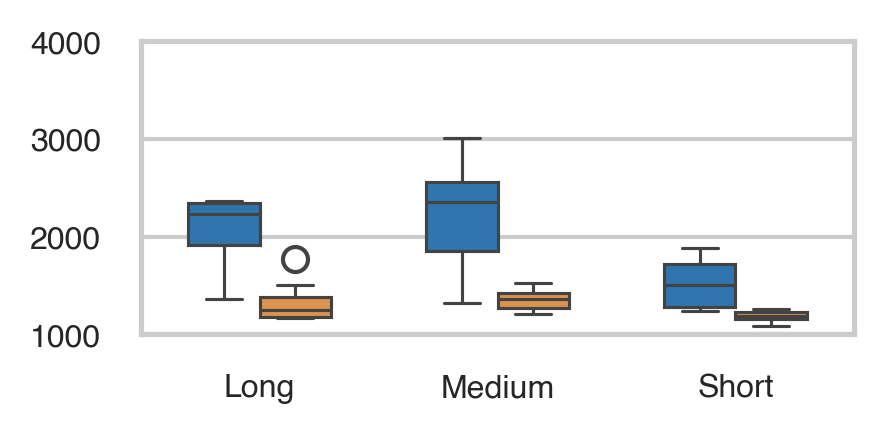

In [41]:
# Order the x-axis by the median judgment time for each sim time condition
my_order = mean_scene_rt.groupby(
    by=["sim_time_condition"]
).judgment_time.median().sort_values(ascending=False).index
# Set the theme parameters
sns.set_theme(
    style='whitegrid',
    font_scale=0.7,
    rc={
        'figure.dpi':300,
        'font.family':'sans-serif',
        'font.sans-serif':['Helvetica'],
        'figure.figsize':(3,1.5),
    },
)
# Create a boxplot of the judgment time by sim time condition and path condition
g = sns.boxplot(
    data=mean_scene_rt,
    x='sim_time_condition',
    y='judgment_time',
    hue='path_condition',
    width=0.6,
    order=my_order,
    linewidth=0.75,
    palette=PATH_PALETTE)
# Set axis labels and limits
g.set_ylabel('')
g.set_xlabel('')
g.set_ylim(1000, 4000)
g.set_xticklabels(['Long', 'Medium', 'Short'])
# Remove the legend
g.legend_.remove()
plt.tight_layout()
# If saving figures, save the figure
if SAVING_FIGURES:
    plt.savefig(
        os.path.join('..', config.FIGURE_STORE, 'rt_replication_a.pdf'),
        dpi=300,
        bbox_inches='tight')

In [42]:
# Test for differences across simulation time conditions
def run_mw_tests(df, cond1, cond2):
    metrics = ['judgment_time']
    results = {}
    for metric in metrics:
        group1 = df[(df['sim_time_condition'] == cond1)][metric]
        group2 = df[(df['sim_time_condition'] == cond2)][metric]
        stat, pval = stats.mannwhitneyu(group1, group2)
        results[metric] = pval
    print(f"\n{cond1} vs {cond2}:")
    for metric, pval in results.items():
        print(f"{metric}: p = {pval:.4f}, U = {stat:.2f}")

In [43]:

# Run all comparisons
run_mw_tests(mean_scene_rt, 'low', 'med')
run_mw_tests(mean_scene_rt, 'med', 'high')
run_mw_tests(mean_scene_rt, 'low', 'high')


low vs med:
judgment_time: p = 0.0070, U = 56.00

med vs high:
judgment_time: p = 0.5591, U = 144.00

low vs high:
judgment_time: p = 0.0302, U = 70.00


In [44]:
# Calculate mean accuracy across scenes, path, and sim time conditions
mean_scene_accuracy = trial_gaze_data[trial_gaze_data['experiment'] == 'exp2'].groupby(
    ['scene_name', 'path_condition', 'sim_time']).correct.mean().reset_index()

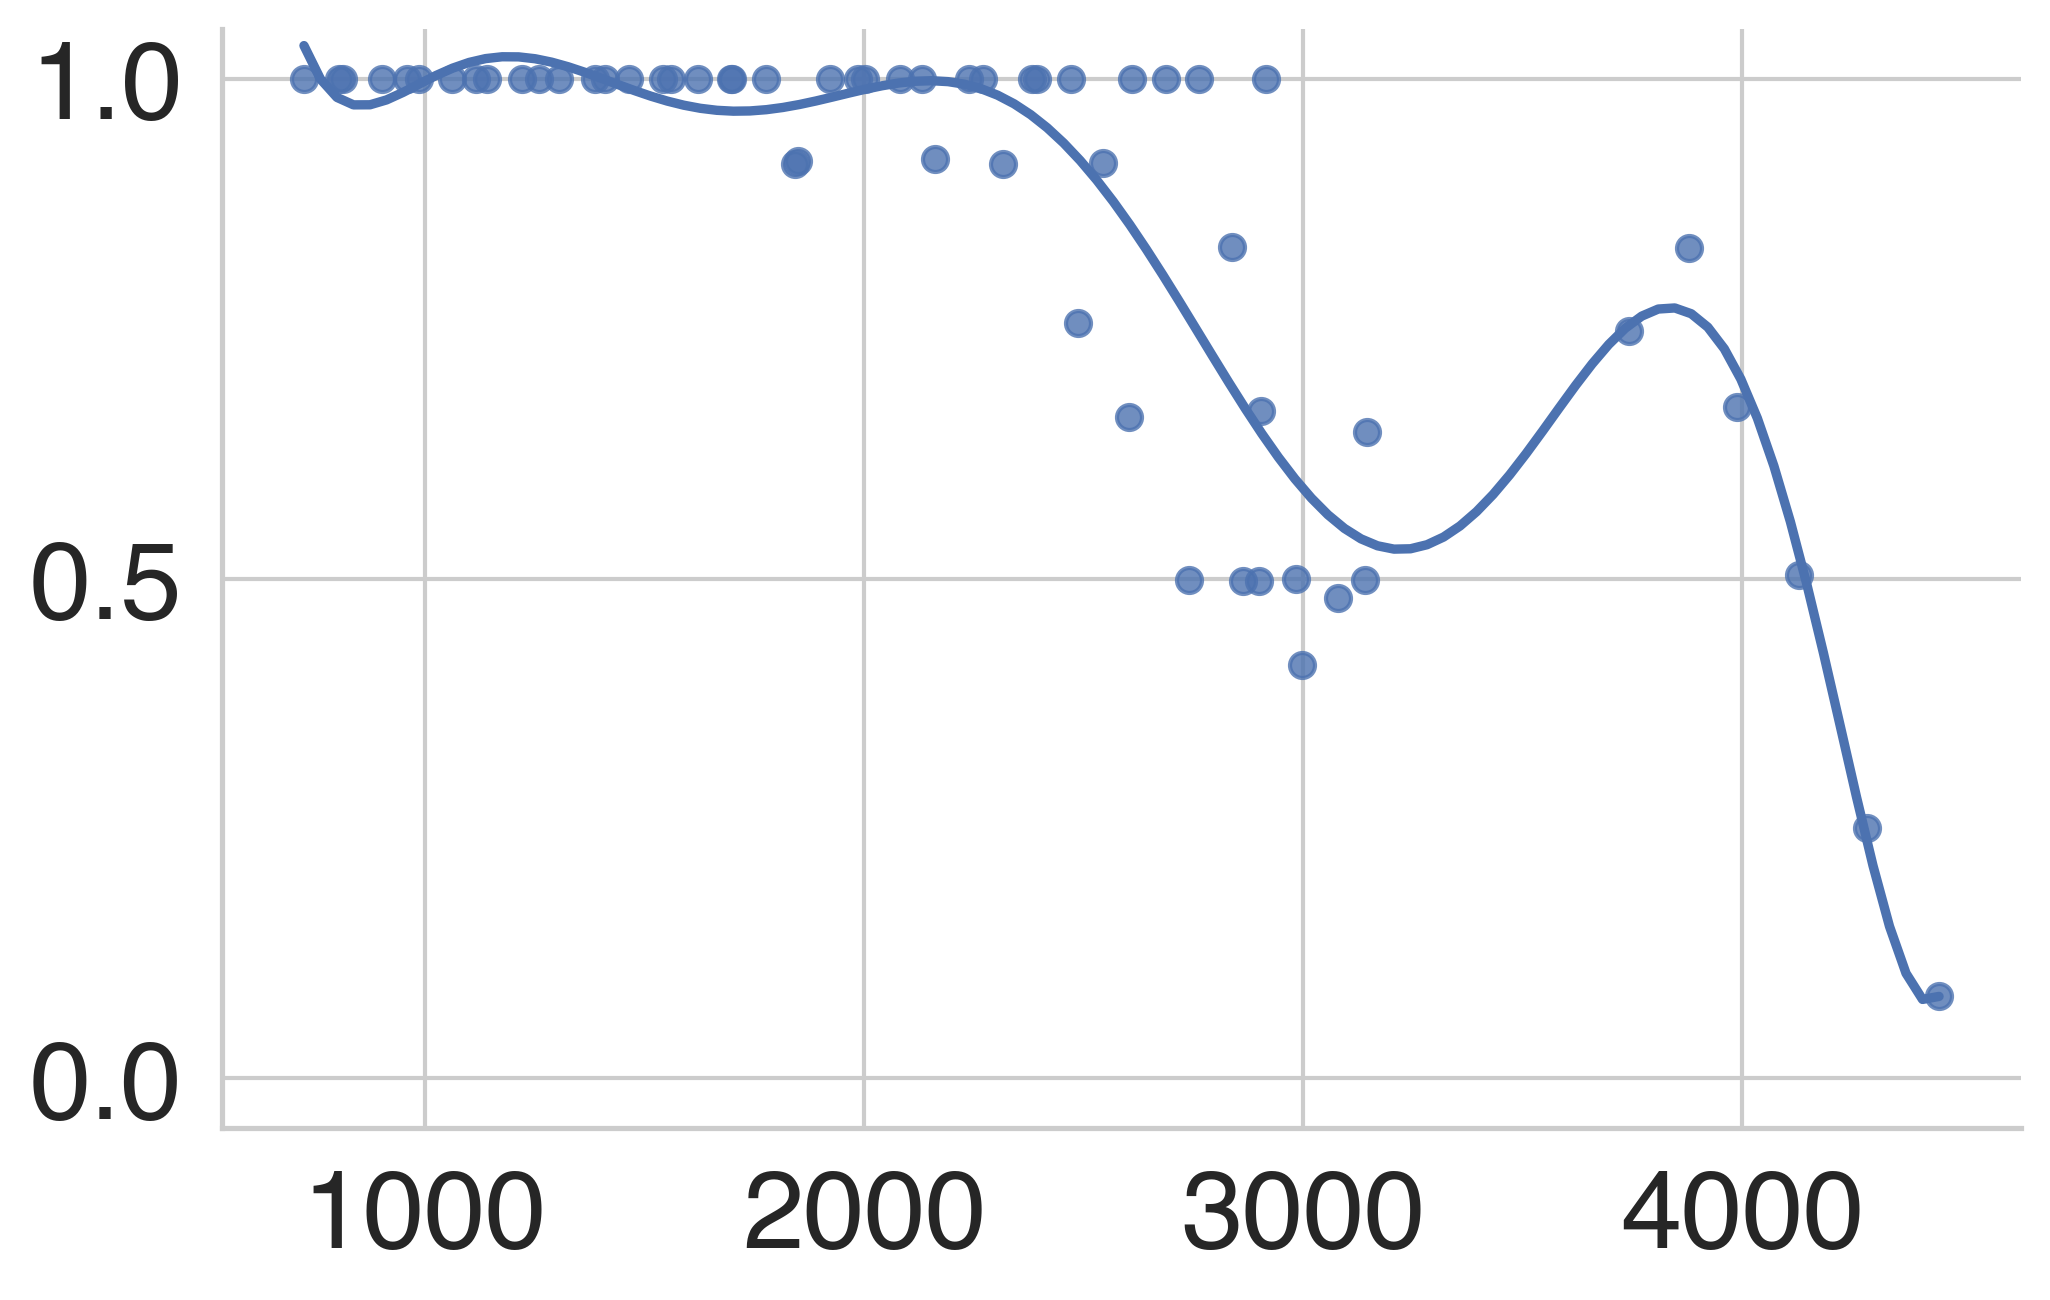

In [46]:
# Set the theme parameters
sns.set_theme(
    style='whitegrid',
    font_scale=2.4,
    rc={
        'figure.dpi': 300,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica'],
    },
)
# Create the lmplot directly - it creates its own figure
g = sns.lmplot(
    data=mean_scene_accuracy,
    x='sim_time',
    y='correct',
    order=8,
    ci=None,
    sharex=False,
    height=5,  # Control figure height
    aspect=1.5,  # Control aspect ratio (width/height)
)
# Adjust the plot settings
g.set(ylim=(-0.05, 1.05))
g.set_axis_labels('', '')
plt.tight_layout()
if SAVING_FIGURES:
    plt.savefig(
        os.path.join('..', config.FIGURE_STORE, 'accuracy_replication.pdf'),
        bbox_inches='tight')